<a href="https://colab.research.google.com/github/subham-28/PyTorch/blob/main/ANN_pytorch_gpu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn
import matplotlib.pyplot as plt

In [5]:
torch.manual_seed(42)

In [6]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [7]:
df=pd.read_csv("/content/fashion-mnist_train.csv")
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


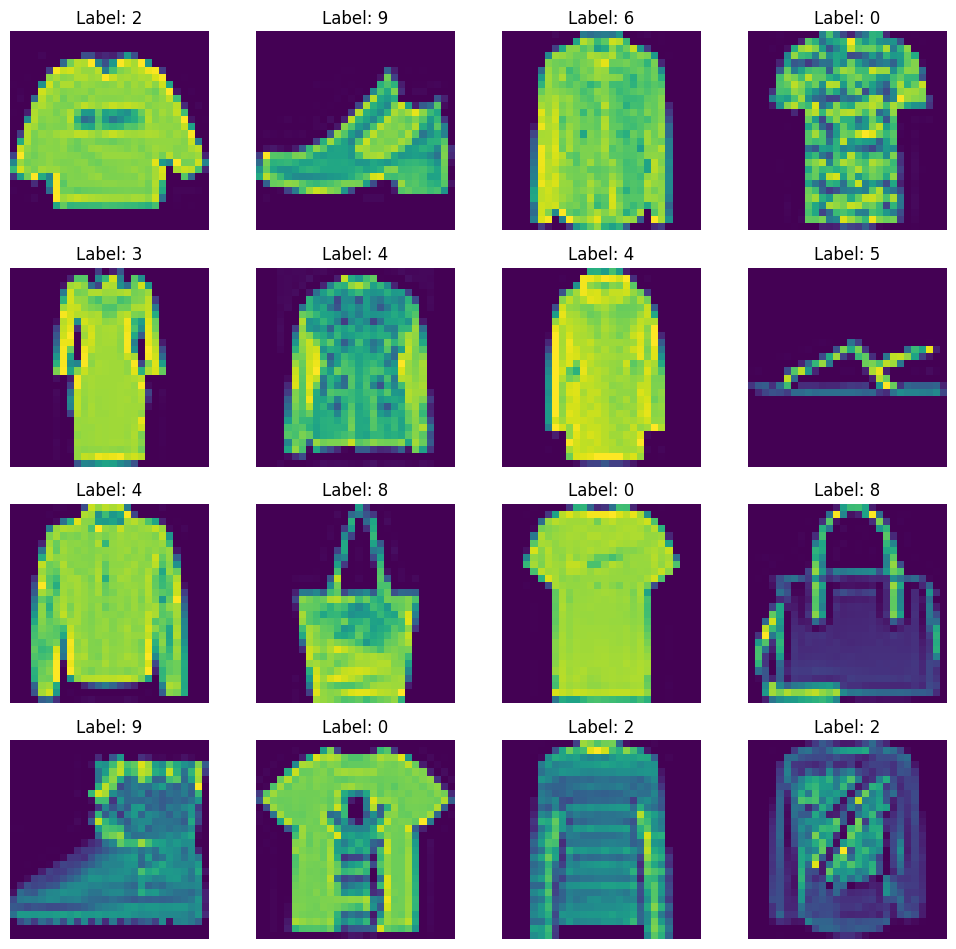

In [8]:
fig, axes=plt.subplots(nrows=4, ncols=4, figsize=(10,10))

for i,ax in enumerate(axes.flat):
  img=df.iloc[i,1:].values.reshape(28,28)
  ax.imshow(img)
  ax.axis("off")
  ax.set_title(f"Label: {df.iloc[i,0]}")
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

In [9]:
x=df.iloc[:,1:].values
y=df.iloc[:,0].values

In [10]:
x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=0.2, random_state=42)

In [11]:
#scaling
x_train=x_train/255.0
x_test=x_test/255.0

In [12]:
#custom dataset class
class CustomDataset(Dataset):
  def __init__(self,features,labels):
    super().__init__()
    self.features=torch.tensor(features, dtype=torch.float32)
    self.labels=torch.tensor(labels, dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self,idx):
    return self.features[idx], self.labels[idx]

In [13]:
train_dataset=CustomDataset(x_train, y_train)
test_dataset=CustomDataset(x_test, y_test)

In [14]:
len(train_dataset)

48000

In [15]:
#create train and test loader
train_loader=DataLoader(train_dataset, batch_size=32, shuffle=True,pin_memory=True)
test_loader=DataLoader(test_dataset, batch_size=32, shuffle=False,pin_memory=True)

In [16]:
#define nn
class MyNN(nn.Module):
  def __init__(self,num_features):
    super().__init__()
    self.model=nn.Sequential(
      nn.Linear(num_features,128),
      nn.ReLU(),
      nn.Linear(128,64),
      nn.ReLU(),
      nn.Linear(64,10)
    )

  def forward(self,features):
    out=self.model(features)
    return out

In [17]:
epochs=100
learning_rate=0.1

In [18]:
# create model
model=MyNN(x_train.shape[1])
model=model.to(device)

#loss func
loss_function=nn.CrossEntropyLoss()

#define optimizer
optimizer=torch.optim.SGD(model.parameters(),lr=learning_rate)

In [19]:
#training loop
for epoch in range(epochs):
  total_epoch_loss=0
  for batch_features, batch_labels in train_loader:
    #move data to gpu
    batch_features=batch_features.to(device)
    batch_labels=batch_labels.to(device)

    #forward pass
    y_pred=model(batch_features)

    #loss
    loss = loss_function(y_pred,batch_labels)

    #zero gradient
    optimizer.zero_grad()

    #backward pass
    loss.backward()

    #update params
    optimizer.step()

    #print loss
    total_epoch_loss+=loss.item()
  total_epoch_loss=total_epoch_loss/len(train_loader)
  print(f"Epoch: {epoch+1}/{epochs} Loss: {total_epoch_loss}")

Epoch: 1/100 Loss: 0.6352872474888961
Epoch: 2/100 Loss: 0.4304986953884363
Epoch: 3/100 Loss: 0.3861262078657746
Epoch: 4/100 Loss: 0.3584607255011797
Epoch: 5/100 Loss: 0.3376494748592377
Epoch: 6/100 Loss: 0.32276468626906474
Epoch: 7/100 Loss: 0.3078539018382629
Epoch: 8/100 Loss: 0.2949818898836772
Epoch: 9/100 Loss: 0.2854692505300045
Epoch: 10/100 Loss: 0.27467058210571604
Epoch: 11/100 Loss: 0.26830569267148774
Epoch: 12/100 Loss: 0.2581421597401301
Epoch: 13/100 Loss: 0.24940819991752505
Epoch: 14/100 Loss: 0.24444738873218497
Epoch: 15/100 Loss: 0.2385919222868979
Epoch: 16/100 Loss: 0.23155899402375021
Epoch: 17/100 Loss: 0.22562562982489665
Epoch: 18/100 Loss: 0.2202964697740972
Epoch: 19/100 Loss: 0.21206334652379155
Epoch: 20/100 Loss: 0.20960091769819458
Epoch: 21/100 Loss: 0.20624992956593632
Epoch: 22/100 Loss: 0.19986103242821993
Epoch: 23/100 Loss: 0.1953041393881043
Epoch: 24/100 Loss: 0.19312163671137145
Epoch: 25/100 Loss: 0.18764107141271233
Epoch: 26/100 Loss: 0

In [20]:
model.eval()

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [21]:
#evaluation
total=0
correct=0

with torch.no_grad():
  for batch_features, batch_labels in test_loader:
    batch_features=batch_features.to(device)
    batch_labels=batch_labels.to(device)

    y_pred=model(batch_features)
    _, predicted=torch.max(y_pred,1)
    total+=batch_labels.shape[0]
    correct+=(predicted==batch_labels).sum().item()

print(f"Accuracy: {correct/total}")

Accuracy: 0.8898333333333334
